In [2]:
import kagglehub

path = kagglehub.dataset_download("parasharmanas/movie-recommendation-system")

print(path)

100%|██████████| 165M/165M [00:01<00:00, 137MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/parasharmanas/movie-recommendation-system/versions/1


In [4]:
import os

print(os.listdir(path))

['ratings.csv', 'movies.csv']


In [5]:
import pandas as pd

movies = pd.read_csv(path + "/movies.csv")
ratings = pd.read_csv(path + "/ratings.csv")

print("Movies Shape:", movies.shape)
print("Ratings Shape:", ratings.shape)

movies.head()

Movies Shape: (62423, 3)
Ratings Shape: (25000095, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [7]:
movie_data = pd.merge(ratings, movies, on="movieId")

movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,296,5.0,1147880044,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,1,306,3.5,1147868817,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,1,307,5.0,1147868828,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,1,665,5.0,1147878820,Underground (1995),Comedy|Drama|War
4,1,899,3.5,1147868510,Singin' in the Rain (1952),Comedy|Musical|Romance


In [8]:
movie_ratings = movie_data.groupby("title").agg(
    average_rating=("rating", "mean"),
    number_of_ratings=("rating", "count")
)

movie_ratings.head()

,average_rating,number_of_ratings
title,,
"""BLOW THE NIGHT!"" Let's Spend the Night Together (1983)",3.000000,1
"""Great Performances"" Cats (1998)",2.896648,179
#1 Cheerleader Camp (2010),2.111111,9
#Captured (2017),3.750000,2
#Female Pleasure (2018),3.666667,3


In [9]:
popular_movies = movie_ratings[
    movie_ratings["number_of_ratings"] > 50
].sort_values(
    by="average_rating",
    ascending=False
)

popular_movies.head(10)

,average_rating,number_of_ratings
title,,
Planet Earth II (2016),4.483096,1124
Planet Earth (2006),4.464797,1747
"Shawshank Redemption, The (1994)",4.413576,81482
Band of Brothers (2001),4.398599,1356
Cosmos,4.326715,277
"Godfather, The (1972)",4.324336,52498
Blue Planet II (2017),4.289833,659
"Usual Suspects, The (1995)",4.284353,55366
Twin Peaks (1989),4.267361,288


In [10]:
print("Top 10 Recommended Movies:\n")

for movie in popular_movies.head(10).index:
    print(movie)

Top 10 Recommended Movies:

Planet Earth II (2016)
Planet Earth (2006)
Shawshank Redemption, The (1994)
Band of Brothers (2001)
Cosmos
Godfather, The (1972)
Blue Planet II (2017)
Usual Suspects, The (1995)
Twin Peaks (1989)
Godfather: Part II, The (1974)


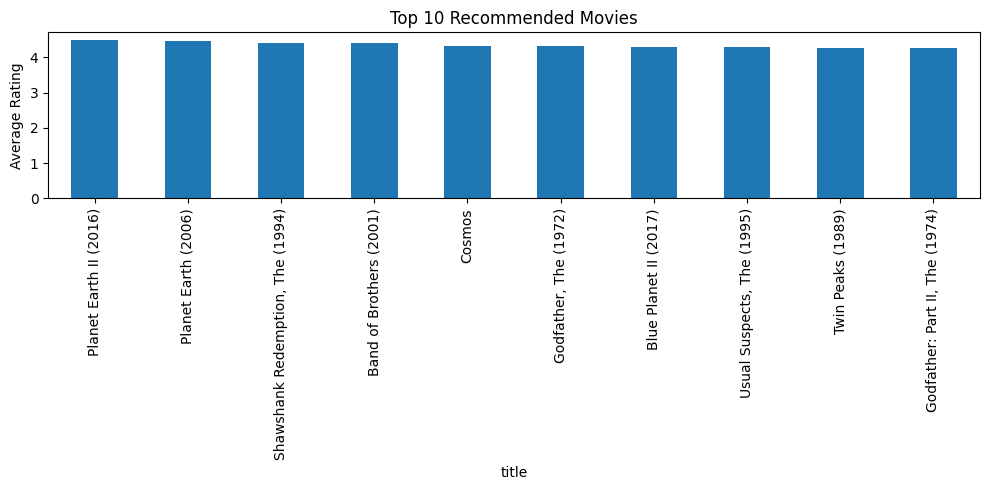

In [11]:
import matplotlib.pyplot as plt

top10 = popular_movies.head(10)

plt.figure(figsize=(10,5))
top10["average_rating"].plot(kind="bar")

plt.title("Top 10 Recommended Movies")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()